NUCASUS = Nuclear Generating Units, Capacity Factor

This dataset tracks the capacity factor of U.S. nuclear generating units from 1957 to present, measured as a percentage. The capacity factor represents how efficiently nuclear plants are operating. specifically what percentage of their maximun possible output they actually generated in a given peroid. A higher capacity factor means plants are running closer to full potential.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("../data/NUCASUS.csv", skiprows=1)

df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Value"])

df.head()

,MSN,YYYYMM,Value,Column_Order,Description,Unit
16,NUCASUS,197301,57.8,5,"Nuclear Generating Units, Capacity Factor",Percent
17,NUCASUS,197302,60.7,5,"Nuclear Generating Units, Capacity Factor",Percent
18,NUCASUS,197303,58.4,5,"Nuclear Generating Units, Capacity Factor",Percent
19,NUCASUS,197304,53.4,5,"Nuclear Generating Units, Capacity Factor",Percent
20,NUCASUS,197305,47.3,5,"Nuclear Generating Units, Capacity Factor",Percent


In [3]:
df.describe()

,YYYYMM,Value,Column_Order
count,689.000000,689.000000,689.0
mean,199907.000000,76.998549,5.0
std,1530.821735,16.164328,0.0
min,197301.000000,34.600000,5.0
25%,198604.000000,61.600000,5.0
50%,199907.000000,80.400000,5.0
75%,201210.000000,92.100000,5.0
max,202513.000000,101.600000,5.0


In [4]:
year_data = df[df["YYYYMM"] % 100 == 13].copy()
year_data["Year"] = year_data["YYYYMM"] // 100
year_data.head()

,MSN,YYYYMM,Value,Column_Order,Description,Unit,Year
28,NUCASUS,197313,53.5,5,"Nuclear Generating Units, Capacity Factor",Percent,1973
41,NUCASUS,197413,47.8,5,"Nuclear Generating Units, Capacity Factor",Percent,1974
54,NUCASUS,197513,55.9,5,"Nuclear Generating Units, Capacity Factor",Percent,1975
67,NUCASUS,197613,54.7,5,"Nuclear Generating Units, Capacity Factor",Percent,1976
80,NUCASUS,197713,63.3,5,"Nuclear Generating Units, Capacity Factor",Percent,1977


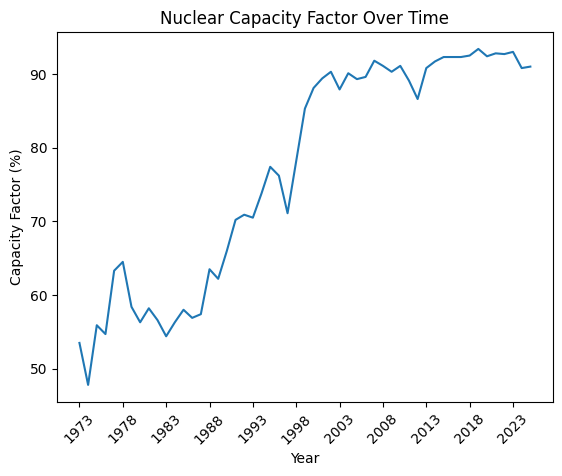

In [5]:
plt.plot(year_data["Year"], year_data["Value"])
plt.xticks(year_data["Year"][::5], rotation=45)

plt.xlabel("Year")
plt.ylabel("Capacity Factor (%)")
plt.title("Nuclear Capacity Factor Over Time")
plt.show()

This graph shows how efficiently U.S. nuclear plants ran each year from 1973 to present. In the 1970s plants were only running at about 50% of their potential, but by the 2000s they improved to around 90%. This tells us nuclear plants got much better at staying online and running at full power over time.

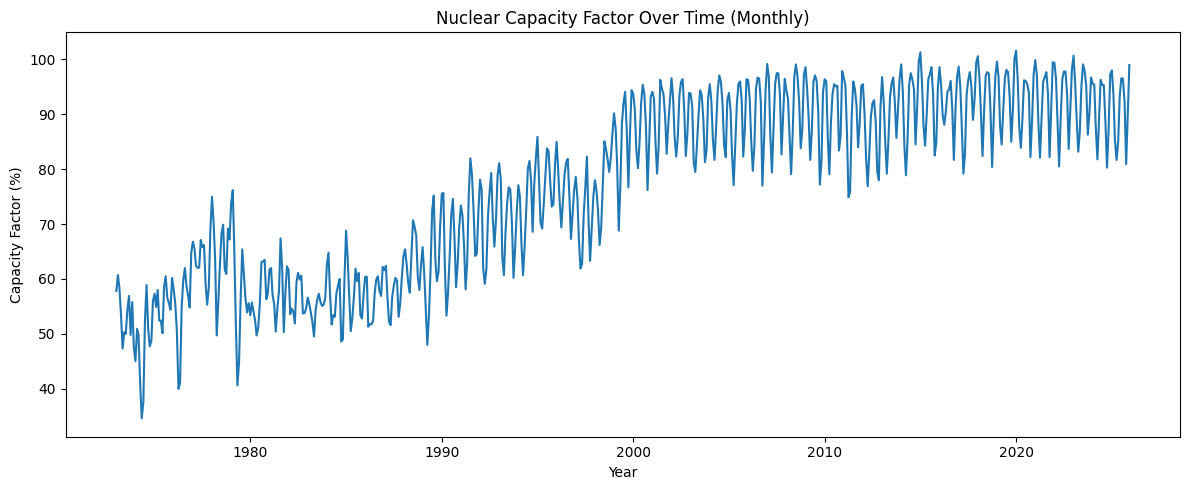

In [6]:
month_data = df[df["YYYYMM"] % 100 != 13].copy()

#Convert YYYYMM to a real date
month_data["Date"] = pd.to_datetime(month_data["YYYYMM"].astype(str), format="%Y%m")

plt.figure(figsize=(12, 5))
plt.plot(month_data["Date"], month_data["Value"])

plt.xlabel("Year")
plt.ylabel("Capacity Factor (%)")
plt.title("Nuclear Capacity Factor Over Time (Monthly)")
plt.tight_layout()
plt.show()

This is the same as the first graph but broken down by month instead of year. The jagged spikes you see each year are from planned shutdowns where plants pause for refueling and maintenance. The overall upward trend is still clear, just with more detail.


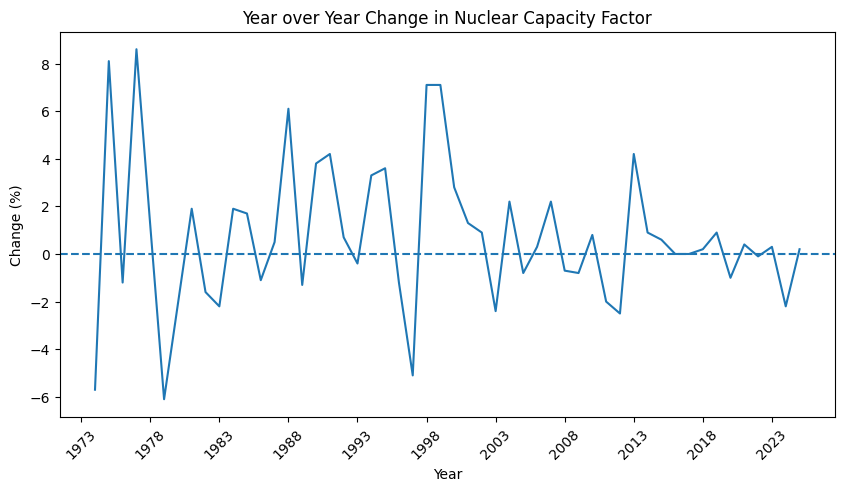

In [7]:
year_data["yoy diff"] = year_data["Value"].diff()

plt.figure(figsize=(10, 5))
plt.plot(year_data["Year"], year_data["yoy diff"])
plt.xticks(year_data["Year"][::5], rotation=45)
plt.axhline(0, linestyle='--')
plt.title("Year over Year Change in Nuclear Capacity Factor")
plt.xlabel("Year")
plt.ylabel("Change (%)")
plt.show()

This graph shows how much the capacity factor went up or down each year compared to the year before. The biggest swings happened in the 1970s and 80s when the industry was still new and unstable. After 2000 the changes became much smaller, meaning nuclear plants were running at a consistently steady level.

In [8]:
lowest_drops = year_data.nsmallest(10, "yoy diff")
print("Biggest Drops:")
print(lowest_drops[["Year", "yoy diff"]])

highest_spikes = year_data.nlargest(10, "yoy diff")
print("\nBiggest Growth:")
print(highest_spikes[["Year", "yoy diff"]])

Biggest Drops:
     Year  yoy diff
106  1979      -6.1
41   1974      -5.7
340  1997      -5.1
535  2012      -2.5
418  2003      -2.4
158  1983      -2.2
691  2024      -2.2
119  1980      -2.1
522  2011      -2.0
145  1982      -1.6

Biggest Growth:
     Year  yoy diff
80   1977       8.6
54   1975       8.1
353  1998       7.1
366  1999       7.1
223  1988       6.1
262  1991       4.2
548  2013       4.2
249  1990       3.8
314  1995       3.6
301  1994       3.3


The biggest single-year drop was in 1979 with -6.1%, which lines up directly with the Three Mile Island accident that year, which triggered stricter safety regulations and temporary shutdowns across the industry. The late 1970s and early 1980s dominate the drops list, reflecting the turbulent period when new safety rules, rising costs, and public opposition were disrupting plant operations. On the growth side, 1977 and 1975 saw the biggest jumps (+8.6% and +8.1%), when many new plants were coming online for the first time and adding large amounts of capacity all at once. The late 1990s also saw strong growth, likely due to operational improvements and longer fuel cycles that kept plants running more continuously.

Adding policy

In [9]:
policy_data = pd.read_csv('../data/policy.csv')

yearly_policy_data = pd.merge(year_data, policy_data, on="Year", how="left")
yearly_policy_data.head(20)


,MSN,YYYYMM,Value,Column_Order,Description_x,Unit,Year,yoy diff,Event_Name,Event_Type,Policy_Indicator,Description_y,Source
0,NUCASUS,197313,53.5,5,"Nuclear Generating Units, Capacity Factor",Percent,1973,NaN,Yom Kippur War / Arab Oil Embargo,War / Energy Security Shock,1.0,Oil supply disruption increased interest in do...,DOE History Timeline
1,NUCASUS,197413,47.8,5,"Nuclear Generating Units, Capacity Factor",Percent,1974,-5.7,Energy Reorganization Act,Regulation,0.0,Abolished the AEC and created the NRC and ERDA...,NRC / U.S. Congress
2,NUCASUS,197513,55.9,5,"Nuclear Generating Units, Capacity Factor",Percent,1975,8.1,NaN,NaN,NaN,NaN,NaN
3,NUCASUS,197613,54.7,5,"Nuclear Generating Units, Capacity Factor",Percent,1976,-1.2,NaN,NaN,NaN,NaN,NaN
4,NUCASUS,197713,63.3,5,"Nuclear Generating Units, Capacity Factor",Percent,1977,8.6,NaN,NaN,NaN,NaN,NaN
5,NUCASUS,197813,64.5,5,"Nuclear Generating Units, Capacity Factor",Percent,1978,1.2,NaN,NaN,NaN,NaN,NaN
6,NUCASUS,197913,58.4,5,"Nuclear Generating Units, Capacity Factor",Percent,1979,-6.1,Three Mile Island Accident,Accident,-1.0,Partial core meltdown sharply reduced public c...,NRC
7,NUCASUS,198013,56.3,5,"Nuclear Generating Units, Capacity Factor",Percent,1980,-2.1,NaN,NaN,NaN,NaN,NaN
8,NUCASUS,198113,58.2,5,"Nuclear Generating Units, Capacity Factor",Percent,1981,1.9,NaN,NaN,NaN,NaN,NaN
9,NUCASUS,198213,56.6,5,"Nuclear Generating Units, Capacity Factor",Percent,1982,-1.6,Nuclear Waste Policy Act,Regulation,-1.0,Created the federal repository framework but a...,DOE / U.S. Congress


In [10]:
yearly_policy_data["Event_Name"] = yearly_policy_data["Event_Name"].fillna("None")
yearly_policy_data["Event_Type"] = yearly_policy_data["Event_Type"].fillna("None")
yearly_policy_data["Policy_Indicator"] = yearly_policy_data["Policy_Indicator"].fillna(0)
yearly_policy_data["cumulative_policy"] = yearly_policy_data["Policy_Indicator"].cumsum()
yearly_policy_data.head(20)

,MSN,YYYYMM,Value,Column_Order,Description_x,Unit,Year,yoy diff,Event_Name,Event_Type,Policy_Indicator,Description_y,Source,cumulative_policy
0,NUCASUS,197313,53.5,5,"Nuclear Generating Units, Capacity Factor",Percent,1973,NaN,Yom Kippur War / Arab Oil Embargo,War / Energy Security Shock,1.0,Oil supply disruption increased interest in do...,DOE History Timeline,1.0
1,NUCASUS,197413,47.8,5,"Nuclear Generating Units, Capacity Factor",Percent,1974,-5.7,Energy Reorganization Act,Regulation,0.0,Abolished the AEC and created the NRC and ERDA...,NRC / U.S. Congress,1.0
2,NUCASUS,197513,55.9,5,"Nuclear Generating Units, Capacity Factor",Percent,1975,8.1,None,None,0.0,NaN,NaN,1.0
3,NUCASUS,197613,54.7,5,"Nuclear Generating Units, Capacity Factor",Percent,1976,-1.2,None,None,0.0,NaN,NaN,1.0
4,NUCASUS,197713,63.3,5,"Nuclear Generating Units, Capacity Factor",Percent,1977,8.6,None,None,0.0,NaN,NaN,1.0
5,NUCASUS,197813,64.5,5,"Nuclear Generating Units, Capacity Factor",Percent,1978,1.2,None,None,0.0,NaN,NaN,1.0
6,NUCASUS,197913,58.4,5,"Nuclear Generating Units, Capacity Factor",Percent,1979,-6.1,Three Mile Island Accident,Accident,-1.0,Partial core meltdown sharply reduced public c...,NRC,0.0
7,NUCASUS,198013,56.3,5,"Nuclear Generating Units, Capacity Factor",Percent,1980,-2.1,None,None,0.0,NaN,NaN,0.0
8,NUCASUS,198113,58.2,5,"Nuclear Generating Units, Capacity Factor",Percent,1981,1.9,None,None,0.0,NaN,NaN,0.0
9,NUCASUS,198213,56.6,5,"Nuclear Generating Units, Capacity Factor",Percent,1982,-1.6,Nuclear Waste Policy Act,Regulation,-1.0,Created the federal repository framework but a...,DOE / U.S. Congress,-1.0


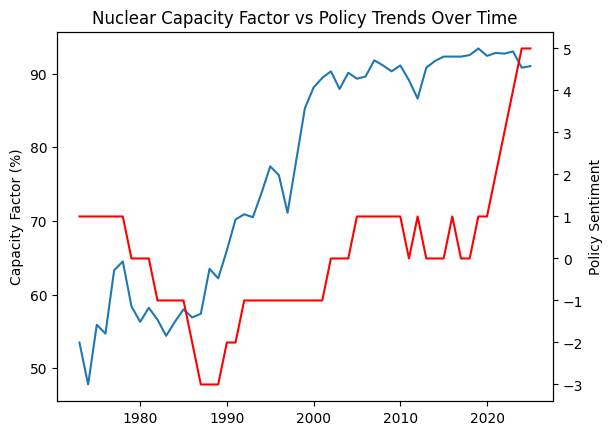

In [11]:
fig, ax1 = plt.subplots()

ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Capacity Factor (%)")

ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["cumulative_policy"], color="red")
ax2.set_ylabel("Policy Sentiment")

plt.title("Nuclear Capacity Factor vs Policy Trends Over Time")
plt.show()

This chart compares how nuclear plants performed (blue) against whether government policies were pro or anti nuclear at the time (red). Even when policies turned negative in the 1980s due to events like Three Mile Island and Chernobyl, plant efficiency kept going up. This shows that bad policy didn't immediately hurt performance, it just slowed down future growth.

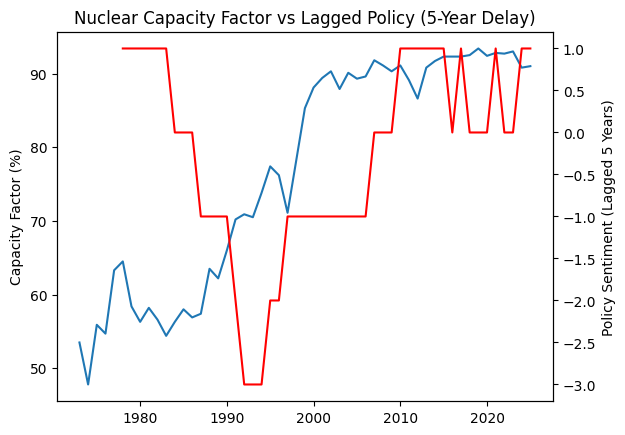

In [12]:
yearly_policy_data["policy_lag_5"] = yearly_policy_data["cumulative_policy"].shift(5)

fig, ax1 = plt.subplots()

ax1.plot(yearly_policy_data["Year"], yearly_policy_data["Value"])
ax1.set_ylabel("Capacity Factor (%)")

ax2 = ax1.twinx()
ax2.plot(yearly_policy_data["Year"], yearly_policy_data["policy_lag_5"], color="red")
ax2.set_ylabel("Policy Sentiment (Lagged 5 Years)")

plt.title("Nuclear Capacity Factor vs Lagged Policy (5-Year Delay)")
plt.show()

This is the same as graph 4 but the policy line is shifted 5 years forward to test whether policy takes time to actually affect plants. The results suggest yes, when policy was very negative around 1990, capacity factor growth eventually slowed down a few years later. This supports the idea that policy impacts nuclear energy in the long run

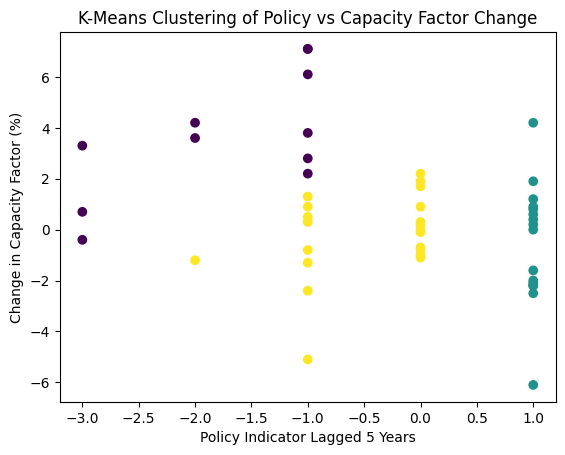

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

kmeans_df = yearly_policy_data[["policy_lag_5", "yoy diff"]].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(kmeans_df)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_df["cluster"] = kmeans.fit_predict(scaled_data)

plt.scatter(
    kmeans_df["policy_lag_5"],
    kmeans_df["yoy diff"],
    c=kmeans_df["cluster"]
)

plt.xlabel("Policy Indicator Lagged 5 Years")
plt.ylabel("Change in Capacity Factor (%)")
plt.title("K-Means Clustering of Policy vs Capacity Factor Change")
plt.show()

This scatter plot groups years into 3 clusters based on how policy sentiment and capacity factor changes relate to each other. The purple dots show years where plants improved a lot even during negative policy periods. The teal dots on the right represent recent years where policy was more positive but changes were small, because plants were already running near maximum efficiency.